In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

print('Environment ready.')

Environment ready.


In [3]:
INDEX_COLS   = ['unit_number', 'time_cycles']
OP_SETTINGS  = ['setting_1', 'setting_2', 'setting_3']
SENSOR_NAMES = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]
COL_NAMES = INDEX_COLS + OP_SETTINGS + SENSOR_NAMES

BASE = '/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps'
READ_KW = dict(sep=r'\s+', header=None, names=COL_NAMES, engine='python')

train = pd.read_csv(f'{BASE}/train_FD001.txt', **READ_KW)
test  = pd.read_csv(f'{BASE}/test_FD001.txt',  **READ_KW)
rul   = pd.read_csv(f'{BASE}/RUL_FD001.txt',   sep=r'\s+', header=None, names=['RUL'], engine='python')

print(f'Train: {train.shape} | Test: {test.shape} | RUL: {rul.shape}')
print(f'Nulls — Train: {train.isnull().sum().sum()} | Test: {test.isnull().sum().sum()}')

Train: (20631, 26) | Test: (13096, 26) | RUL: (100, 1)
Nulls — Train: 0 | Test: 0


**2 Data Control**

In [4]:
# --- 2a. Remove constant (dead) sensors ---

dead = [c for c in train.columns if train[c].nunique() <= 1]
train.drop(columns=dead, inplace=True)
test.drop(columns=dead, inplace=True)
print(f'Dropped {len(dead)} dead sensors: {dead}')

# --- 2b. Compute + clip RUL ---
RUL_CAP = 125

max_cycle = train.groupby('unit_number')['time_cycles'].max().rename('max_cycle')
train = train.join(max_cycle, on='unit_number')
train['RUL'] = (train['max_cycle'] - train['time_cycles']).clip(upper=RUL_CAP)
train.drop(columns='max_cycle', inplace=True)

print(f'RUL capped at {RUL_CAP}. Distribution:\n{train["RUL"].describe().round(1).to_string()}')

Dropped 7 dead sensors: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
RUL capped at 125. Distribution:
count    20631.0
mean        86.8
std         41.7
min          0.0
25%         51.0
50%        103.0
75%        125.0
max        125.0


 **3 Exploratory Data Analysis**

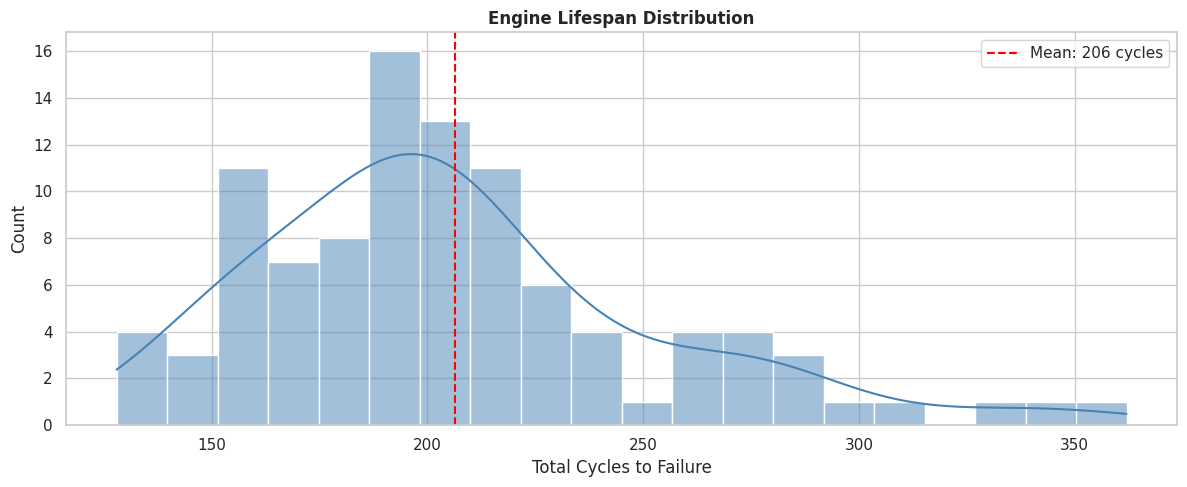

In [5]:
# --- 3a. Engine lifespan distribution ---
lifespan = train.groupby('unit_number')['time_cycles'].max()

plt.figure()
sns.histplot(lifespan, kde=True, bins=20, color='steelblue')
plt.axvline(lifespan.mean(), color='red', linestyle='--', label=f'Mean: {lifespan.mean():.0f} cycles')
plt.title('Engine Lifespan Distribution', fontweight='bold')
plt.xlabel('Total Cycles to Failure')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

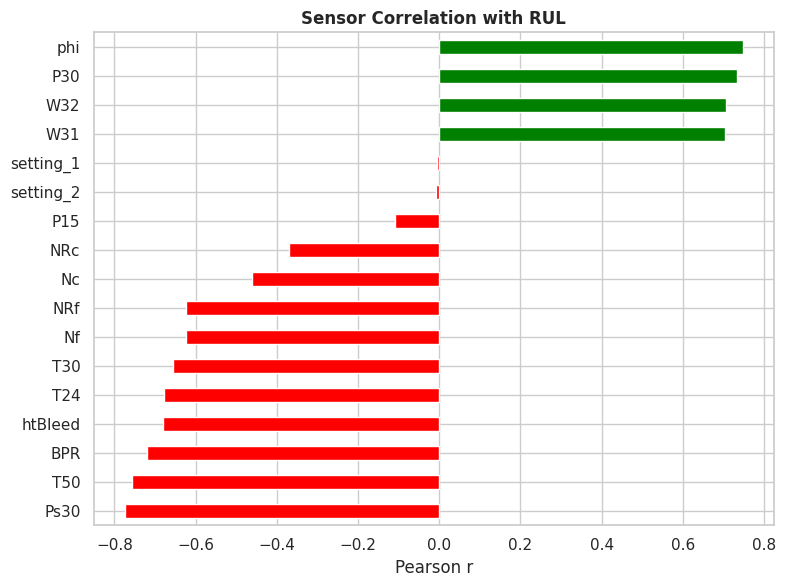

Top 5 informative sensors: ['Ps30', 'T50', 'phi', 'P30', 'BPR']


In [6]:
# --- 3b. Sensor correlation with RUL ---
feature_cols = [c for c in train.columns if c not in ['unit_number', 'time_cycles', 'RUL']]
rul_corr = train[feature_cols + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(8, 6))
rul_corr.plot(kind='barh', color=['red' if v < 0 else 'green' for v in rul_corr])
plt.title('Sensor Correlation with RUL', fontweight='bold')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

# Top 5 most correlated sensors
top_sensors = rul_corr.abs().nlargest(5).index.tolist()
print('Top 5 informative sensors:', top_sensors)

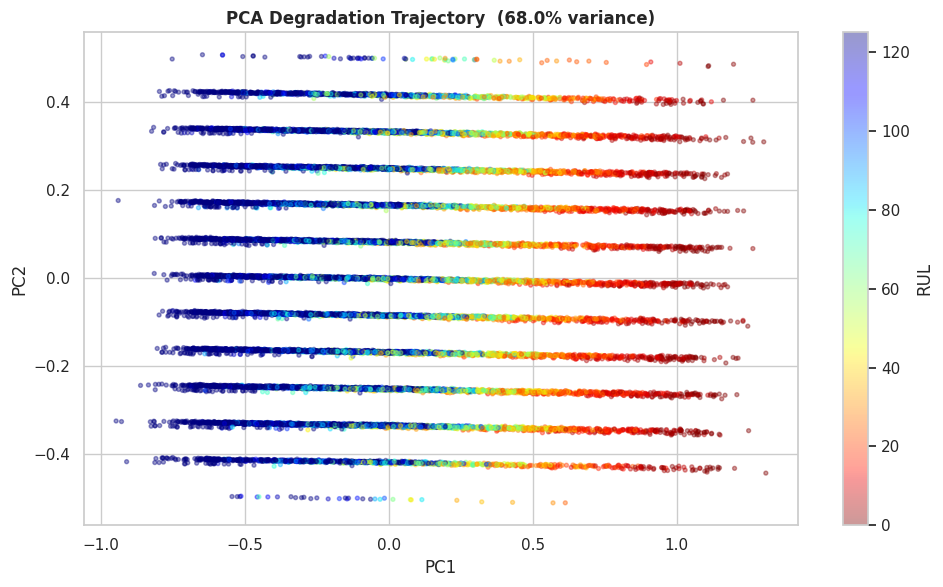

In [7]:
# --- 3d. PCA degradation trajectory ---
pca = PCA(n_components=2, random_state=42)
scaled_tmp = MinMaxScaler().fit_transform(train[feature_cols])
pcs = pca.fit_transform(scaled_tmp)

plt.figure(figsize=(10, 6))
sc = plt.scatter(pcs[:, 0], pcs[:, 1], c=train['RUL'], cmap='jet_r', alpha=0.4, s=8)
plt.colorbar(sc, label='RUL')
plt.title(f'PCA Degradation Trajectory  ({pca.explained_variance_ratio_.sum():.1%} variance)', fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

**Preprocessing & Train/Test Split**

In [8]:
# MinMax scale sensor features only (fit on train, transform both)
scaler = MinMaxScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols]  = scaler.transform(test[feature_cols])

X_train = train[feature_cols]
y_train = train['RUL']

# Test: predict at last observed cycle per engine
X_test  = test.groupby('unit_number')[feature_cols].last()
y_true  = rul['RUL'].values

assert len(X_test) == len(y_true), 'Shape mismatch!'
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (20631, 17) | X_test: (100, 17)


In [9]:
results = []

def evaluate(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    r2   = r2_score(y_true, pred)
    results.append({'Model': name, 'RMSE': round(rmse, 2), 'R²': round(r2, 4)})
    print(f'{name:25s}  RMSE={rmse:.2f}  R²={r2:.2%}')
    return pred

models = [
    (LinearRegression(),                                                    'Linear Regression'),
    (RandomForestRegressor(n_estimators=200, max_depth=12,
                           min_samples_leaf=3, n_jobs=-1, random_state=42), 'Random Forest'),
    (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                  subsample=0.8, colsample_bytree=0.8,
                  n_jobs=-1, random_state=42),                              'XGBoost'),
    (LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8,
                   num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                   n_jobs=-1, random_state=42, verbose=-1),                 'LightGBM'),
]

preds = {name: evaluate(m, name) for m, name in models}

Linear Regression          RMSE=21.90  R²=72.22%
Random Forest              RMSE=18.18  R²=80.85%
XGBoost                    RMSE=17.76  R²=81.73%
LightGBM                   RMSE=17.88  R²=81.49%


,Model,RMSE,R²
0,XGBoost,17.76,0.8173
1,LightGBM,17.88,0.8149
2,Random Forest,18.18,0.8085
3,Linear Regression,21.90,0.7222


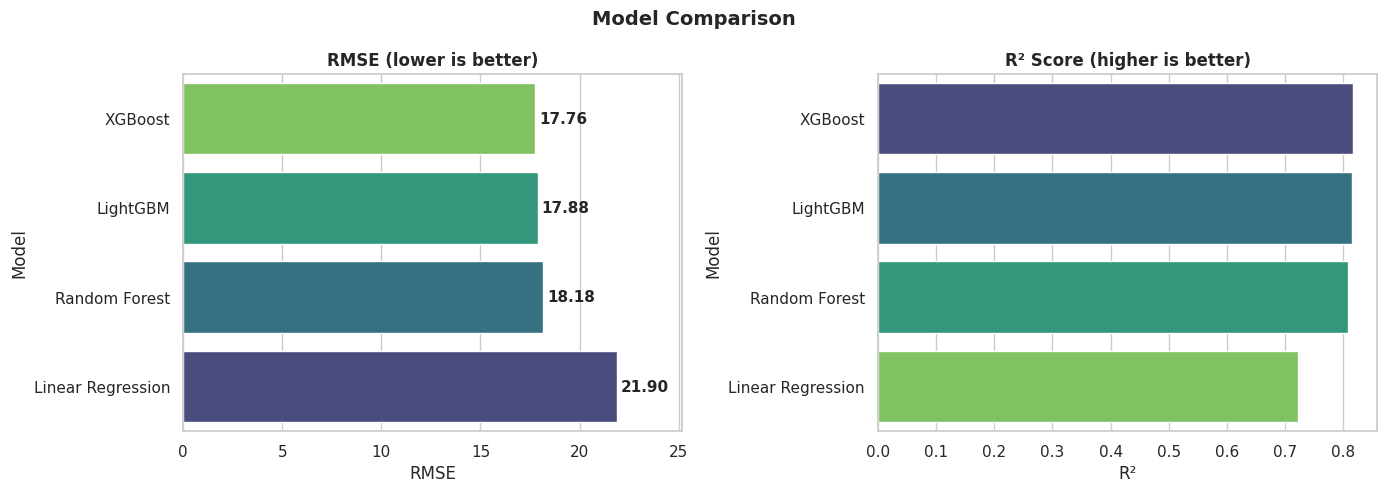


✅ Best model: XGBoost  (RMSE=17.76)


In [10]:
# --- Leaderboard ---
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='RMSE', y='Model', palette='viridis_r', ax=axes[0])
for i, v in enumerate(results_df['RMSE']):
    axes[0].text(v + 0.2, i, f'{v:.2f}', va='center', fontweight='bold')
axes[0].set_title('RMSE (lower is better)', fontweight='bold')
axes[0].set_xlim(0, results_df['RMSE'].max() * 1.15)

sns.barplot(data=results_df, x='R²', y='Model', palette='viridis', ax=axes[1])
axes[1].set_title('R² Score (higher is better)', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_name = results_df.iloc[0]['Model']
print(f'\n✅ Best model: {best_name}  (RMSE={results_df.iloc[0]["RMSE"]})')

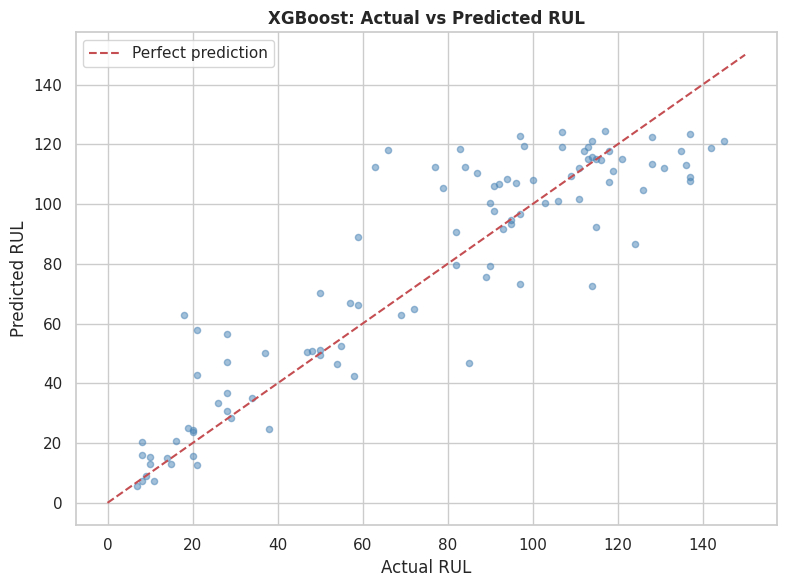

In [11]:
# --- Actual vs Predicted scatter ---
best_pred = preds[best_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_true, best_pred, alpha=0.5, s=20, color='steelblue')
lims = [0, max(y_true.max(), best_pred.max()) + 5]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title(f'{best_name}: Actual vs Predicted RUL', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'XGBoost'

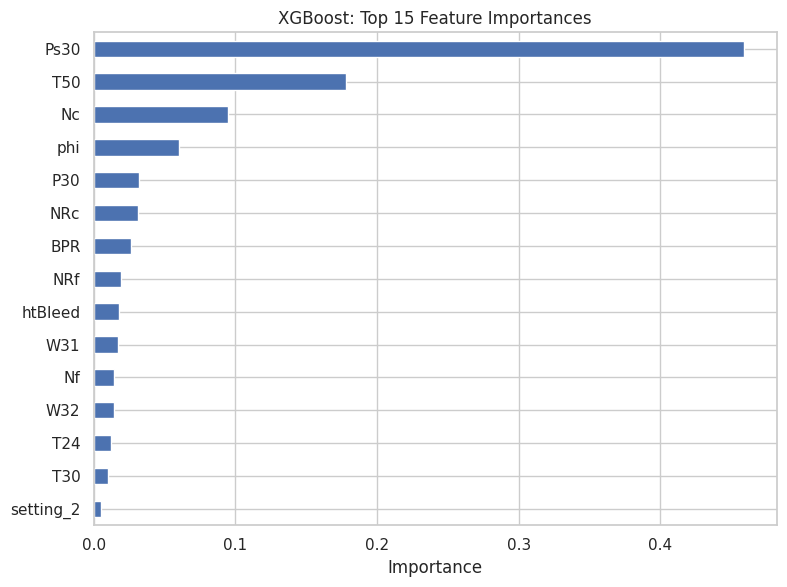

In [17]:
if hasattr(best_model_obj, 'feature_importances_'):
    imp = pd.Series(
        best_model_obj.feature_importances_,
        index=feature_cols
    ).nlargest(15).sort_values()

    plt.figure(figsize=(8, 6))
    imp.plot(kind='barh')
    plt.title(f'{best_name}: Top 15 Feature Importances')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

In [15]:
model_dict = {name: model for model, name in models}
best_model_obj = model_dict[best_name]

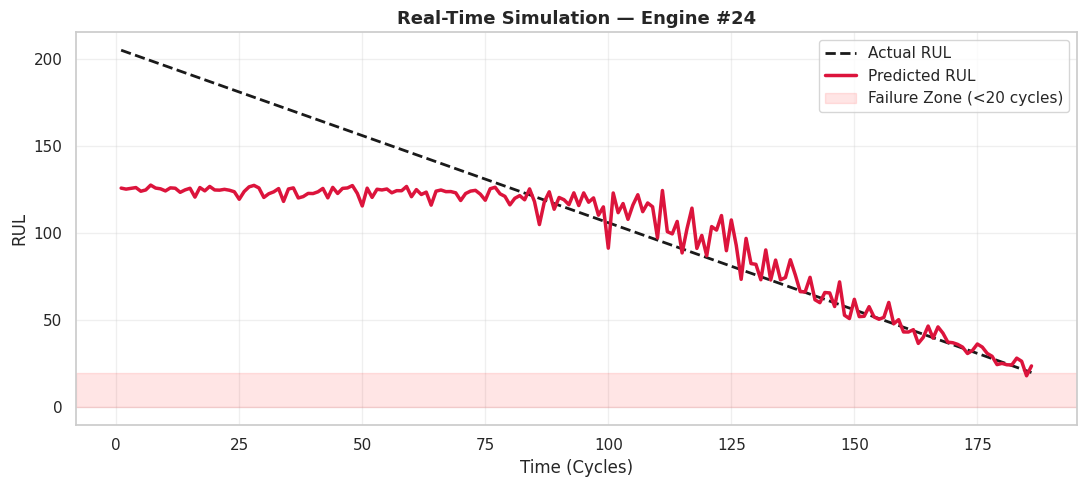

In [18]:
def simulate_engine(unit_id, model, test_df, true_rul_df, feature_cols, n_units=5):
    """Reconstruct RUL trajectory for a given test engine."""
    engine_data = test_df[test_df['unit_number'] == unit_id].copy()
    pred_rul    = model.predict(engine_data[feature_cols])

    final_rul   = true_rul_df.iloc[unit_id - 1]['RUL']
    n_cycles    = len(engine_data)
    actual_rul  = (final_rul + n_cycles - np.arange(n_cycles) - 1).tolist()

    plt.figure(figsize=(11, 5))
    plt.plot(engine_data['time_cycles'], actual_rul, 'k--', label='Actual RUL', linewidth=2)
    plt.plot(engine_data['time_cycles'], pred_rul,   color='crimson', linewidth=2.5, label='Predicted RUL')
    plt.axhspan(0, 20, color='red', alpha=0.1, label='Failure Zone (<20 cycles)')
    plt.title(f'Real-Time Simulation — Engine #{unit_id}', fontweight='bold', fontsize=13)
    plt.xlabel('Time (Cycles)')
    plt.ylabel('RUL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

simulate_engine(24, best_model_obj, test, rul, feature_cols)

In [20]:
joblib.dump(best_model_obj, 'best_rul_model.pkl')
joblib.dump(scaler,         'scaler.pkl')
print(f'Saved: best_rul_model.pkl ({best_name}), scaler.pkl')

Saved: best_rul_model.pkl (XGBoost), scaler.pkl


Testing With Sample Input

Predicted Remaining Useful Life (RUL): 107.78 cycles


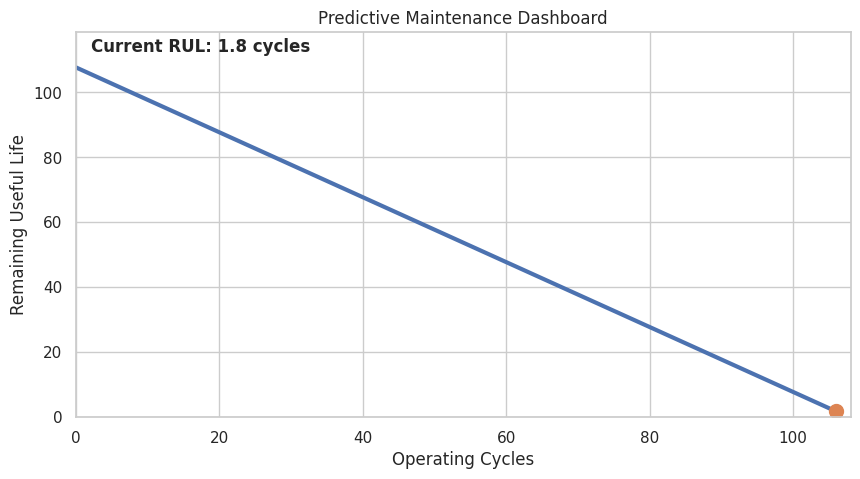

In [26]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# Load model and scaler
model = joblib.load("best_rul_model.pkl")
scaler = joblib.load("scaler.pkl")

# Input data
new_data = {
    'setting_1': 0.0,
    'setting_2': 0.0,
    'setting_3': 100.0,
    'T2': 518.67,
    'T24': 641.82,
    'T30': 1589.70,
    'T50': 1500.60,
    'P2': 14.62,
    'P15': 22.61,
    'P30': 554.36,
    'Nf': 2388.06,
    'Nc': 9046.19,
    'epr': 1.30,
    'Ps30': 47.47,
    'phi': 521.66,
    'NRf': 2388.02,
    'NRc': 8138.62,
    'BPR': 8.4195,
    'farB': 0.03,
    'htBleed': 392,
    'Nf_dmd': 2388,
    'PCNfR_dmd': 100,
    'W31': 39.06,
    'W32': 23.42
}

# Create dataframe
input_df = pd.DataFrame([new_data])

# Same feature order as training
input_df = input_df[feature_cols]

# Scale
input_scaled = scaler.transform(input_df)

# Predict
predicted_rul = float(model.predict(input_scaled)[0])

print(f"Predicted Remaining Useful Life (RUL): {predicted_rul:.2f} cycles")

# -------------------------------
# Animated RUL Visualization
# -------------------------------

future_cycles = np.arange(0, int(predicted_rul) + 1)
remaining_rul = predicted_rul - future_cycles

fig, ax = plt.subplots(figsize=(10, 5))

ax.set_xlim(0, len(future_cycles))
ax.set_ylim(0, predicted_rul * 1.1)

ax.set_title("Predictive Maintenance Dashboard")
ax.set_xlabel("Operating Cycles")
ax.set_ylabel("Remaining Useful Life")

line, = ax.plot([], [], lw=3)
point, = ax.plot([], [], marker='o', markersize=10)

rul_text = ax.text(
    0.02,
    0.95,
    "",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold"
)

def update(frame):
    x = future_cycles[:frame]
    y = remaining_rul[:frame]

    line.set_data(x, y)

    if len(x) > 0:
        point.set_data([x[-1]], [y[-1]])
        rul_text.set_text(f"Current RUL: {y[-1]:.1f} cycles")

    return line, point, rul_text

ani = FuncAnimation(
    fig,
    update,
    frames=len(future_cycles),
    interval=40,
    blit=True,
    repeat=False
)

HTML(ani.to_jshtml())